In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [ ]:
!pip install rasterio
!pip install rasterstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 104.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 65.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import geopandas as gpd
import joblib
from rasterio.mask import mask
import os
import glob
import rasterio
import pandas as pd
import numpy as np
from rasterio.plot import show
from shapely.geometry import Point
from tqdm import tqdm  # For progress tracking
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
path1 = '/content/drive/MyDrive/Kamatira Model Data/Forest'#my raster file path
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson'


In [ ]:
gdf = gpd.read_file(path2)
gdf.head(5)

,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,geometry
0,KAMATIRA,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",None,None,None,clampToGround,-1,0,-1,None,None,"MULTIPOLYGON Z (((35.16513 1.28577 0, 35.16564..."


In [ ]:
import os
import glob

# search for .tif files
tif_files = glob.glob(os.path.join(path1, '*.tif'))

# Print the list of .tif files
if tif_files:
    print("Found .tif files:")
    for file in tif_files:
        print(file)
else:
    print("No .tif files found in the directory.")


Found .tif files:
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2020.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2024.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_1995.tif


In [ ]:
import os
import glob
import geopandas as gpd
from rasterio.mask import mask
import rasterio

# Paths
tif_path = '/content/drive/MyDrive/Kamatira Model Data/Forest'
output_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/Clipped'
os.makedirs(output_path, exist_ok=True)



# Combine into one geometry
if gdf.empty or gdf.geometry.is_empty.any():
    raise ValueError("gdf has no valid geometry.")
merged_geom = gdf.unary_union

# List all .tif files
tif_files = glob.glob(os.path.join(tif_path, '*.tif'))
print("Found .tif files:")
for f in tif_files:
    print(f)

# Process each raster
for tif_file in tif_files:
    try:
        with rasterio.open(tif_file) as src:
            if gdf.crs != src.crs:
                print("Reprojecting geometry to match raster CRS.")
                merged_geom = gdf.to_crs(src.crs).unary_union

            # Use a different nodata value (e.g. 255)
            out_image, out_transform = mask(
                src, [merged_geom], crop=True, nodata=255  # not 0!
            )

            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "nodata": 255  # match what we masked with
            })

        filename = os.path.basename(tif_file).replace('classified_', 'clipped_')
        output_file = os.path.join(output_path, filename)

        with rasterio.open(output_file, "w", **out_meta) as dest:
            dest.write(out_image)

        print(f" Clipped and saved: {output_file}")

    except Exception as e:
        print(f" Error processing {tif_file}: {e}")


/tmp/ipython-input-9-607556371.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geom = gdf.unary_union


Found .tif files:
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2020.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2024.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Forest/classified_image_1995.tif
 Clipped and saved: /content/drive/MyDrive/Kamatira Model Data/Forest/Clipped/clipped_image_2015.tif
 Clipped and saved: /content/drive/MyDrive/Kamatira Model Data/Forest/Clipped/clipped_image_2020.tif
 Clipped and saved: /content/drive/MyDrive/Kamatira Model Data/Forest/Clipped/clipped_image_2024.tif
 Clipped and saved: /content/drive/MyDrive/Kamatira Model Data/Forest/C

In [ ]:
gdf1 = gpd.read_file(path2)
gdf1.tail(5)

,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,geometry
0,KAMATIRA,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",None,None,None,clampToGround,-1,0,-1,None,None,"MULTIPOLYGON Z (((35.16513 1.28577 0, 35.16564..."


In [ ]:
import os
import glob
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Paths
input_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/Clipped'
output_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles'
os.makedirs(output_path, exist_ok=True)

# List all matching .tif files (no size restriction)
raster_files = glob.glob(os.path.join(input_path, 'clipped_*.tif'))
print(f"Found {len(raster_files)} raster files to process.\n")

for raster_file in raster_files:
    try:
        with rasterio.open(raster_file) as src:
            all_shapes = []
            width, height = src.width, src.height
            block_size = 1024  # Adjust as needed

            nodata = src.nodata

            for row in range(0, height, block_size):
                for col in range(0, width, block_size):
                    window = rasterio.windows.Window(col, row, block_size, block_size)
                    image = src.read(1, window=window)
                    transform = src.window_transform(window)

                    # Respect nodata value if defined
                    if nodata is not None:
                        mask_data = image != nodata
                    else:
                        mask_data = image != 0  # Default mask

                    results = (
                        {"properties": {"class": int(value)}, "geometry": shape(geom)}
                        for geom, value in shapes(image, mask=mask_data, transform=transform)
                    )
                    all_shapes.extend(results)

        if not all_shapes:
            print(f" No features extracted from: {raster_file}")
            continue

        gdf = gpd.GeoDataFrame.from_features(all_shapes, crs=src.crs)

        county_name = os.path.basename(raster_file).replace('Forest_', '').replace('.tif', '')
        out_file = os.path.join(output_path, f'Polygons_{county_name}.geojson')
        gdf.to_file(out_file, driver='GeoJSON')

        print(f" Polygons saved: {out_file} | Classes: {gdf['class'].unique().tolist()}")

    except Exception as e:
        print(f" Error processing {raster_file}: {e}")


Found 8 raster files to process.

 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2015.geojson | Classes: [1, 2, 0]
 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2020.geojson | Classes: [0, 1, 2]
 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2024.geojson | Classes: [0, 1, 2]
 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2000.geojson | Classes: [1, 2, 0]
 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2010.geojson | Classes: [2, 1, 0]
 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2005.geojson | Classes: [2, 1, 0]
 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_1990.geojson | Classes: [0, 2, 1]
 Polygons saved: /content/drive/MyD

In [ ]:
gdf = gpd.read_file('/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2015.geojson')
gdf.tail(5)

,class,geometry
2064,1,"POLYGON ((35.23844 1.27157, 35.23844 1.2713, 3..."
2065,0,"POLYGON ((35.23871 1.2713, 35.23871 1.27112, 3..."
2066,2,"POLYGON ((35.23844 1.2713, 35.23844 1.27103, 3..."
2067,1,"POLYGON ((35.23844 1.27103, 35.23844 1.27049, ..."
2068,2,"POLYGON ((35.23844 1.27049, 35.23844 1.2704, 3..."


In [ ]:
import os
import glob
import geopandas as gpd

# Paths
input_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles'
geojson_files = glob.glob(os.path.join(input_path, 'Polygons_clipped_image_*.geojson'))

for file in geojson_files:
    try:
        gdf = gpd.read_file(file)

        # Project to a metric CRS for accurate area (e.g., UTM or EPSG:3857)
        gdf_metric = gdf.to_crs(epsg=3857)

        # Calculate area in square meters, then convert to hectares
        gdf['area_ha'] = gdf_metric.geometry.area / 10_000  # 10,000 m² in a hectare

        # Save back to the same GeoJSON file (overwrite)
        gdf.to_file(file, driver='GeoJSON')

        print(f" Appended 'area_ha' and updated: {file}")

    except Exception as e:
        print(f" Error processing {file}: {e}")


 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2015.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2020.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2024.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2000.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2010.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2005.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_1990.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_cli

In [ ]:
gdf = gpd.read_file('/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2015.geojson')
gdf.tail(10)

,class,area_ha,AGB_tons,CO2_tons,geometry
2059,2,0.090022,12.442867,5.848148,"POLYGON ((35.23871 1.27237, 35.23871 1.2721, 3..."
2060,1,0.057514,6.530160,3.069175,"POLYGON ((35.23898 1.27237, 35.23898 1.2721, 3..."
2061,1,0.090022,10.221119,4.803926,"POLYGON ((35.23871 1.2721, 35.23871 1.27183, 3..."
2062,2,0.022506,3.110717,1.462037,"POLYGON ((35.23898 1.2721, 35.23898 1.27183, 3..."
2063,2,0.257563,35.600420,16.732197,"POLYGON ((35.23844 1.2721, 35.23844 1.27157, 3..."
2064,1,0.135033,15.331675,7.205887,"POLYGON ((35.23844 1.27157, 35.23844 1.2713, 3..."
2065,0,0.012503,5.459844,2.566127,"POLYGON ((35.23871 1.2713, 35.23871 1.27112, 3..."
2066,2,0.090022,12.442862,5.848145,"POLYGON ((35.23844 1.2713, 35.23844 1.27103, 3..."
2067,1,0.100025,11.356793,5.337693,"POLYGON ((35.23844 1.27103, 35.23844 1.27049, ..."
2068,2,0.005001,0.691270,0.324897,"POLYGON ((35.23844 1.27049, 35.23844 1.2704, 3..."


In [ ]:
import geopandas as gpd
import os

# AGB constants by class
agb_constants = {
    0: 436.68,  # class 0
    1: 113.54,  # class 1
    2: 138.22   # class 2
}

co2_factor = 0.47  # IPCC carbon conversion factor

# Folder where the GeoJSON files are located
geojson_folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"

# Loop over all GeoJSON files
for file in os.listdir(geojson_folder):
    if file.endswith(".geojson") and "Polygons_clipped_image" in file:
        file_path = os.path.join(geojson_folder, file)
        gdf = gpd.read_file(file_path)

        # Ensure class and area fields exist
        if 'class' not in gdf.columns or 'area_ha' not in gdf.columns:
            print(f" Missing 'class' or 'area_ha' in: {file}")
            continue

        # Compute AGB and CO2 based on class
        gdf['AGB_tons'] = gdf.apply(lambda row: row['area_ha'] * agb_constants.get(row['class'], 0), axis=1)
        gdf['CO2_tons'] = gdf['AGB_tons'] * co2_factor

        # Save updated GeoJSON
        gdf.to_file(file_path, driver='GeoJSON')
        print(f" Appended AGB and CO2 columns to: {file_path}")


 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2015.geojson
 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2020.geojson
 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2024.geojson
 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2000.geojson
 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2010.geojson
 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_2005.geojson
 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_clipped_image_1990.geojson
 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Poly

**LULC Scenario Modelling**

In [ ]:
# Install required packages
!pip install rasterio geopandas tensorflow matplotlib tqdm -q

Available years: [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]


100%|██████████| 8/8 [00:02<00:00,  2.79it/s]


Raster stack shape: (8, 799, 2081)
Training samples: 777134


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:48:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Model trained.
🧾 Prediction saved to: /content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2024_XGB.tif


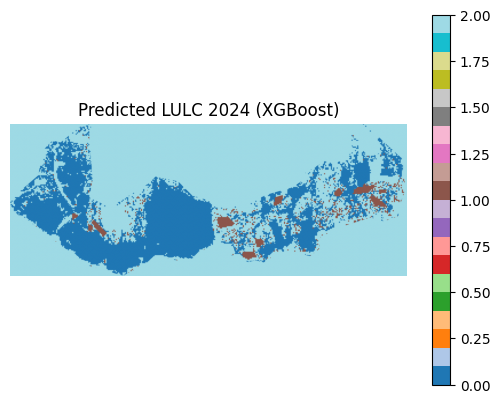

In [ ]:
# Imports
import rasterio
from rasterio.enums import Resampling
import numpy as np
import os
from tqdm import tqdm
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

#  Step 1: Load rasters
folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/Clipped"

# Sorted list of files based on year
years = sorted([
    f for f in os.listdir(folder) if f.endswith(".tif") and "clipped_image" in f
], key=lambda x: int(x.split("_")[-1].split(".")[0]))

year_ints = [int(f.split("_")[-1].split(".")[0]) for f in years]
print("Available years:", year_ints)

# Step 2: Determine min shape and resize all rasters
shapes = []
for file in years:
    with rasterio.open(os.path.join(folder, file)) as src:
        shapes.append((src.height, src.width))
min_shape = np.min(shapes, axis=0)

stack = []
for file in tqdm(years):
    with rasterio.open(os.path.join(folder, file)) as src:
        data = src.read(
            out_shape=(1, min_shape[0], min_shape[1]),
            resampling=Resampling.nearest
        )[0]
        stack.append(data)

stack = np.array(stack)  # shape: (time, H, W)
print("Raster stack shape:", stack.shape)

# Step 3: Define input-output years
input_years = [2000, 2005, 2010, 2015, 2020]
label_year = 2024

year_idx = {year: i for i, year in zip(range(len(stack)), year_ints)}

# Ensure all requested years exist
assert all(y in year_idx for y in input_years + [label_year]), "Year missing from stack!"

# Step 4: Prepare training data
X = np.stack([stack[year_idx[y]] for y in input_years], axis=-1)  # (H, W, T)
y = stack[year_idx[label_year]]  # (H, W)

# Flatten to tabular format
X_flat = X.reshape(-1, X.shape[-1])
y_flat = y.flatten()

# Remove NoData (255)
mask_valid = y_flat != 255
X_clean = X_flat[mask_valid]
y_clean = y_flat[mask_valid]

print("Training samples:", X_clean.shape[0])

# Step 5: Train XGBoost model
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_clean, y_clean)
print(" Model trained.")

# Step 6: Predict for future (2024) using input years
X_future = np.stack([stack[year_idx[y]] for y in input_years], axis=-1)
X_future_flat = X_future.reshape(-1, X_future.shape[-1])

y_pred = model.predict(X_future_flat)
y_pred_raster = y_pred.reshape(min_shape)

# Step 7: Save prediction
out_path = "/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2024_XGB.tif"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

# Use one of the original rasters as reference for metadata
ref_file = os.path.join(folder, [f for f in years if "2020" in f][0])
with rasterio.open(ref_file) as src:
    meta = src.meta.copy()
    meta.update({
        "height": min_shape[0],
        "width": min_shape[1],
        "count": 1,
        "dtype": rasterio.uint8
    })
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(y_pred_raster.astype(np.uint8), 1)

print(f"🧾 Prediction saved to: {out_path}")

# Optional: Quick visualization
plt.imshow(y_pred_raster, cmap='tab20')
plt.title("Predicted LULC 2024 (XGBoost)")
plt.axis('off')
plt.colorbar()
plt.show()


 2035 prediction saved to: /content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_XGB.tif


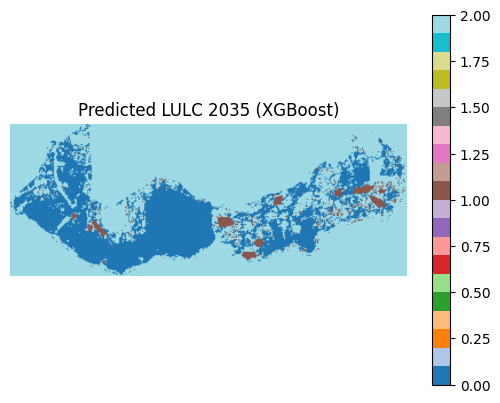

In [ ]:
# --- Step 1–2 remain unchanged ---

# Step 3: Define input-output years for 2035 prediction
input_years = [2005, 2010, 2015, 2020, 2024]  # adjust as needed
label_year = 2035  # Target year

# Add dummy 2035 index for stacking prediction (we don't have real raster for it)
year_idx = {year: i for i, year in zip(range(len(stack)), year_ints)}

# Reuse trained model from previous steps or retrain as needed
# Step 6: Predict future LULC for 2035
X_future = np.stack([stack[year_idx[y]] for y in input_years], axis=-1)
X_future_flat = X_future.reshape(-1, X_future.shape[-1])

y_pred = model.predict(X_future_flat)
y_pred_raster = y_pred.reshape(min_shape)

# Step 7: Save prediction
out_path_2035 = "/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_XGB.tif"
os.makedirs(os.path.dirname(out_path_2035), exist_ok=True)

# Use metadata from an existing raster
with rasterio.open(ref_file) as src:
    meta = src.meta.copy()
    meta.update({
        "height": min_shape[0],
        "width": min_shape[1],
        "count": 1,
        "dtype": rasterio.uint8
    })
    with rasterio.open(out_path_2035, 'w', **meta) as dst:
        dst.write(y_pred_raster.astype(np.uint8), 1)

print(f" 2035 prediction saved to: {out_path_2035}")

# Optional: Visualization
plt.imshow(y_pred_raster, cmap='tab20')
plt.title("Predicted LULC 2035 (XGBoost)")
plt.axis('off')
plt.colorbar()
plt.show()


In [ ]:
# Path to ground truth
gt_2024_path = os.path.join(folder, [f for f in years if "2024" in f][0])

with rasterio.open(gt_2024_path) as src:
    y_true = src.read(1, out_shape=(min_shape[0], min_shape[1]), resampling=Resampling.nearest)

print("Ground truth shape:", y_true.shape)


Ground truth shape: (799, 2081)


In [ ]:
# Flatten both arrays
y_true_flat = y_true.flatten()
y_pred_flat = y_pred_raster.flatten()

# Apply mask to remove NoData (assumed as 255)
valid_mask = y_true_flat != 255
y_true_clean = y_true_flat[valid_mask]
y_pred_clean = y_pred_flat[valid_mask]

print("Valid pixels for accuracy:", y_true_clean.shape[0])


Valid pixels for accuracy: 777134


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Print metrics
print("Overall Accuracy:", accuracy_score(y_true_clean, y_pred_clean))
print("\nClassification Report:")
print(classification_report(y_true_clean, y_pred_clean))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_clean, y_pred_clean))


Overall Accuracy: 0.766830430787998

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86    416429
           1       0.62      0.29      0.39     98908
           2       0.68      0.78      0.72    261797

    accuracy                           0.77    777134
   macro avg       0.71      0.65      0.66    777134
weighted avg       0.76      0.77      0.75    777134


Confusion Matrix:
[[363971   4256  48202]
 [ 21034  28295  49579]
 [ 44916  13217 203664]]


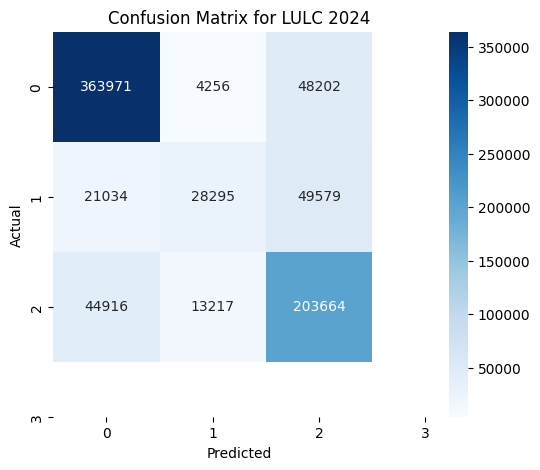

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true_clean, y_pred_clean)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for LULC 2024")
plt.show()


Available years: [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]


100%|██████████| 8/8 [00:00<00:00, 49.53it/s]


Raster stack shape: (8, 799, 2081)
Training samples: 777134


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:06:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Model trained on 2000–2015 to predict 2020.
 Future projection for 2024 saved to: /content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2024_XGB_projected.tif


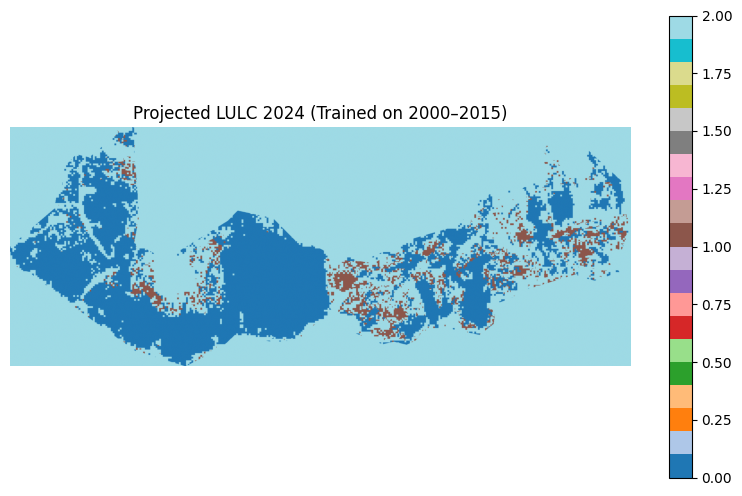

In [ ]:
# Imports
import rasterio
from rasterio.enums import Resampling
import numpy as np
import os
from tqdm import tqdm
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Step 1: Load rasters
folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/Clipped"

# Sorted list of raster files by year
years = sorted([
    f for f in os.listdir(folder) if f.endswith(".tif") and "clipped_image" in f
], key=lambda x: int(x.split("_")[-1].split(".")[0]))

year_ints = [int(f.split("_")[-1].split(".")[0]) for f in years]
print("Available years:", year_ints)

# Step 2: Resize to minimum shape
shapes = []
for file in years:
    with rasterio.open(os.path.join(folder, file)) as src:
        shapes.append((src.height, src.width))
min_shape = np.min(shapes, axis=0)

stack = []
for file in tqdm(years):
    with rasterio.open(os.path.join(folder, file)) as src:
        data = src.read(
            out_shape=(1, min_shape[0], min_shape[1]),
            resampling=Resampling.nearest
        )[0]
        stack.append(data)

stack = np.array(stack)  # shape: (time, H, W)
print("Raster stack shape:", stack.shape)

# Step 3: Define training and prediction setup
input_years = [2000, 2005, 2010, 2015]  # Input years for training and prediction
train_label_year = 2020                # Use 2020 as label (since we don't have 2024)
predict_label_year = 2024             # Future prediction target

year_idx = {year: i for i, year in zip(range(len(stack)), year_ints)}
assert all(y in year_idx for y in input_years + [train_label_year, predict_label_year]), "Missing years!"

# Step 4: Prepare training data
X_train = np.stack([stack[year_idx[y]] for y in input_years], axis=-1)
y_train = stack[year_idx[train_label_year]]

X_train_flat = X_train.reshape(-1, X_train.shape[-1])
y_train_flat = y_train.flatten()

mask_valid = y_train_flat != 255
X_clean = X_train_flat[mask_valid]
y_clean = y_train_flat[mask_valid]

print("Training samples:", X_clean.shape[0])

# Step 5: Train model
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_clean, y_clean)
print(" Model trained on 2000–2015 to predict 2020.")

# Step 6: Predict for 2024
X_future = np.stack([stack[year_idx[y]] for y in input_years], axis=-1)
X_future_flat = X_future.reshape(-1, X_future.shape[-1])
y_pred = model.predict(X_future_flat)
y_pred_raster = y_pred.reshape(min_shape)

# Step 7: Save prediction
out_path = "/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2024_XGB_projected.tif"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

# Use 2020 raster as reference
ref_file = os.path.join(folder, [f for f in years if "2020" in f][0])
with rasterio.open(ref_file) as src:
    meta = src.meta.copy()
    meta.update({
        "height": min_shape[0],
        "width": min_shape[1],
        "count": 1,
        "dtype": rasterio.uint8
    })
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(y_pred_raster.astype(np.uint8), 1)

print(f" Future projection for 2024 saved to: {out_path}")

# Step 8: Visualize
plt.figure(figsize=(10, 6))
plt.imshow(y_pred_raster, cmap='tab20')
plt.title("Projected LULC 2024 (Trained on 2000–2015)")
plt.axis('off')
plt.colorbar()
plt.show()


In [ ]:
import geopandas as gpd
from rasterio.mask import mask

# 🔹 Paths
predicted_path = "/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_XGB.tif"
clip_output_path = "/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_XGB_predicted.tif"
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# 🔹 Read vector
gdf = gpd.read_file(vector_path)
gdf = gdf.to_crs("EPSG:4326")  # Optional: force CRS match if needed

# 🔹 Read and clip raster
with rasterio.open(predicted_path) as src:
    out_image, out_transform = mask(src, gdf.geometry, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# 🔹 Save clipped raster
with rasterio.open(clip_output_path, "w", **out_meta) as dest:
    dest.write(out_image)

print(f" Clipped prediction saved to: {clip_output_path}")


 Clipped prediction saved to: /content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_XGB_predicted.tif


/tmp/ipython-input-10-3514788371.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', np.max(masked_data) + 1)  # Discrete colormap


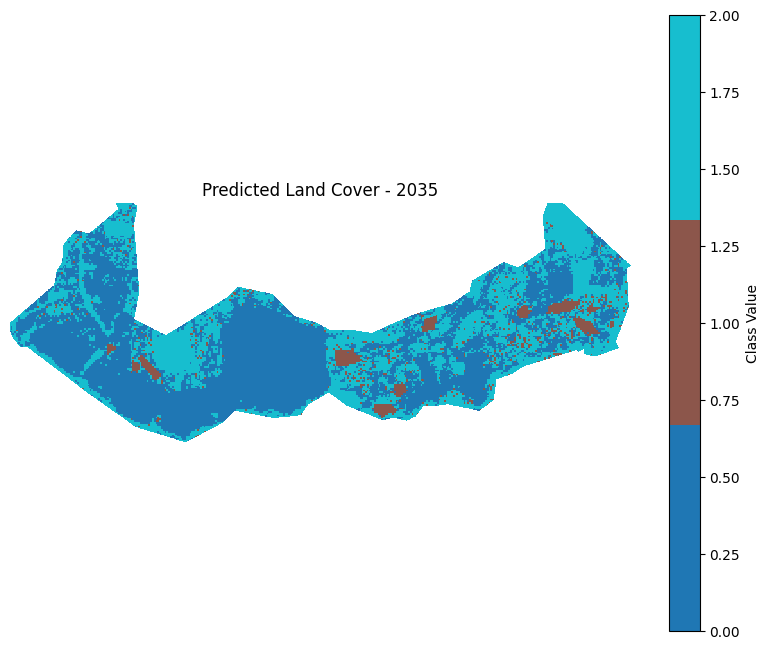

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path to the clipped raster
tif_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_XGB_predicted.tif'

# Open and read the raster
with rasterio.open(tif_path) as src:
    img = src.read(1)
    nodata_value = src.nodata  # Use actual nodata from metadata

    # Mask nodata values only
    masked_data = np.ma.masked_where(img == nodata_value, img)

    # Plot
    plt.figure(figsize=(10, 8))
    cmap = plt.cm.get_cmap('tab10', np.max(masked_data) + 1)  # Discrete colormap
    im = plt.imshow(masked_data, cmap=cmap, interpolation='none')
    plt.colorbar(im, label='Class Value')
    plt.title('Predicted Land Cover - 2035')
    plt.axis('off')
    plt.show()


/tmp/ipython-input-9-653091261.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', np.max(masked_data) + 1)  # Discrete colormap


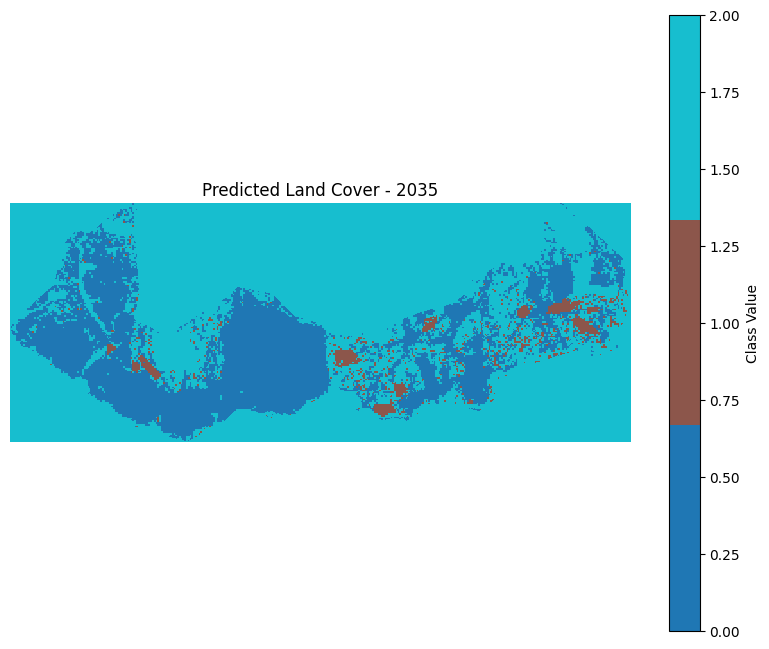

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path to the clipped raster
tif_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_RF.tif'

# Open and read the raster
with rasterio.open(tif_path) as src:
    img = src.read(1)
    nodata_value = src.nodata  # Use actual nodata from metadata

    # Mask nodata values only
    masked_data = np.ma.masked_where(img == nodata_value, img)

    # Plot
    plt.figure(figsize=(10, 8))
    cmap = plt.cm.get_cmap('tab10', np.max(masked_data) + 1)  # Discrete colormap
    im = plt.imshow(masked_data, cmap=cmap, interpolation='none')
    plt.colorbar(im, label='Class Value')
    plt.title('Predicted Land Cover - 2035')
    plt.axis('off')
    plt.show()


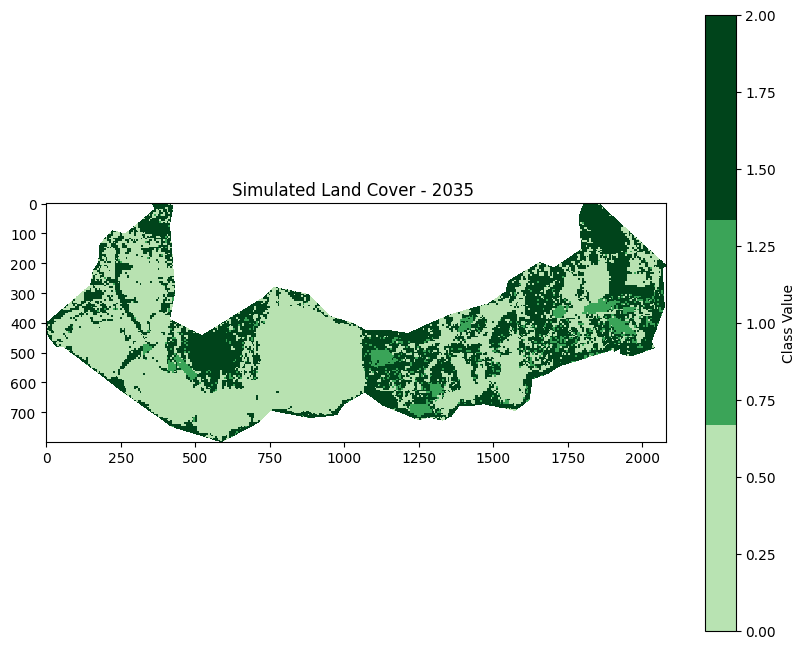

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Path to the clipped raster
tif_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_RF_clipped.tif'

# Open and read the raster
with rasterio.open(tif_path) as src:
    img = src.read(1)
    nodata_value = src.nodata

    # Mask nodata
    masked_data = np.ma.masked_where(img == nodata_value, img)

    # Define custom green shades (max class should match the max class value)
    num_classes = int(np.max(masked_data)) + 1
    greens = plt.cm.Greens(np.linspace(0.3, 1, num_classes))  # Avoid very light green
    custom_green_cmap = ListedColormap(greens)

    # Plot
    plt.figure(figsize=(10, 8))
    im = plt.imshow(masked_data, cmap=custom_green_cmap, interpolation='none')
    plt.colorbar(im, label='Class Value')
    plt.title('Simulated Land Cover - 2035 ')
    plt.axis('on')
    plt.show()


Available years: [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]


100%|██████████| 8/8 [00:00<00:00, 20.45it/s]


Raster stack shape: (8, 799, 2081)
Training samples: 777134
 Random Forest model trained.
 Future prediction saved to: /content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_RF.tif


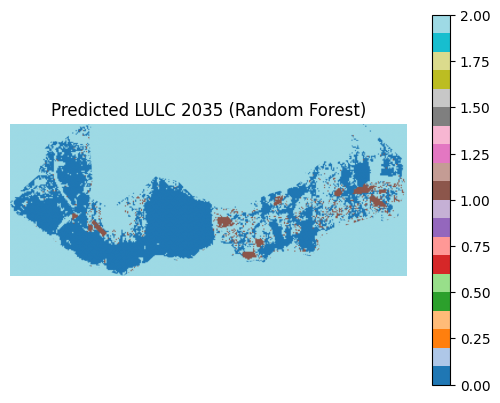

In [ ]:
# Imports
import rasterio
from rasterio.enums import Resampling
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Step 1: Load rasters
folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/Clipped"

years = sorted([
    f for f in os.listdir(folder) if f.endswith(".tif") and "clipped_image" in f
], key=lambda x: int(x.split("_")[-1].split(".")[0]))

year_ints = [int(f.split("_")[-1].split(".")[0]) for f in years]
print("Available years:", year_ints)

# Step 2: Resize all rasters to smallest shape
shapes = []
for file in years:
    with rasterio.open(os.path.join(folder, file)) as src:
        shapes.append((src.height, src.width))
min_shape = np.min(shapes, axis=0)

stack = []
for file in tqdm(years):
    with rasterio.open(os.path.join(folder, file)) as src:
        data = src.read(
            out_shape=(1, min_shape[0], min_shape[1]),
            resampling=Resampling.nearest
        )[0]
        stack.append(data)

stack = np.array(stack)  # shape: (time, H, W)
print("Raster stack shape:", stack.shape)

# Step 3: Input years for prediction
input_years = [2000, 2005, 2010, 2015, 2020]

# Pick label from a year you already have (2024) — use it for training
label_year = 2024  # We assume this is available as ground truth

year_idx = {year: i for i, year in zip(range(len(stack)), year_ints)}
assert all(y in year_idx for y in input_years + [label_year]), "Missing years!"

# Step 4: Prepare training data
X = np.stack([stack[year_idx[y]] for y in input_years], axis=-1)  # shape: (H, W, T)
y = stack[year_idx[label_year]]  # (H, W)

X_flat = X.reshape(-1, X.shape[-1])
y_flat = y.flatten()

# Remove NoData
mask_valid = y_flat != 255
X_clean = X_flat[mask_valid]
y_clean = y_flat[mask_valid]

print("Training samples:", X_clean.shape[0])

# Step 5: Train model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
model.fit(X_clean, y_clean)
print(" Random Forest model trained.")

# Step 6: Predict LULC for 2035 (future) based on past inputs
X_future = np.stack([stack[year_idx[y]] for y in input_years], axis=-1)
X_future_flat = X_future.reshape(-1, X_future.shape[-1])

y_pred = model.predict(X_future_flat)
y_pred_raster = y_pred.reshape(min_shape)

# Step 7: Save output
out_path = "/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions/predicted_LULC_2035_RF.tif"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

ref_file = os.path.join(folder, [f for f in years if "2020" in f][0])
with rasterio.open(ref_file) as src:
    meta = src.meta.copy()
    meta.update({
        "height": min_shape[0],
        "width": min_shape[1],
        "count": 1,
        "dtype": rasterio.uint8
    })
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(y_pred_raster.astype(np.uint8), 1)

print(f" Future prediction saved to: {out_path}")

# Step 8: Visualization
plt.imshow(y_pred_raster, cmap='tab20')
plt.title("Predicted LULC 2035 (Random Forest)")
plt.axis('off')
plt.colorbar()
plt.show()


Accuracy on 2024: 0.7676

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86    416429
           1       0.63      0.28      0.39     98908
           2       0.68      0.78      0.72    261797

    accuracy                           0.77    777134
   macro avg       0.72      0.65      0.66    777134
weighted avg       0.76      0.77      0.75    777134



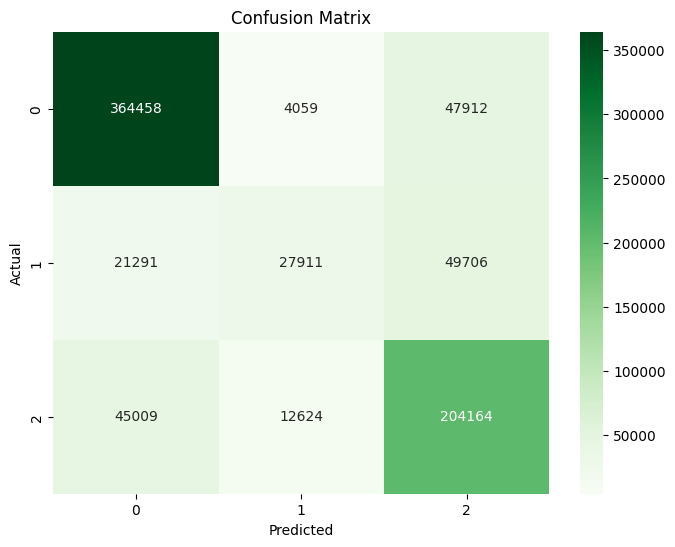

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Compare prediction to actual 2024 raster
y_true = stack[year_idx[2024]].flatten()
mask_valid = y_true != 255

accuracy = accuracy_score(y_true[mask_valid], y_pred[mask_valid])
print(f"Accuracy on 2024: {accuracy:.4f}")

# Optional: more detailed metrics
print("\nClassification Report:")
print(classification_report(y_true[mask_valid], y_pred[mask_valid]))

# Confusion matrix
import seaborn as sns
cm = confusion_matrix(y_true[mask_valid], y_pred[mask_valid])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import os
import glob
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Paths
input_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/Predictions'
output_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles'
os.makedirs(output_path, exist_ok=True)

# List all matching .tif files (no size restriction)
raster_files = glob.glob(os.path.join(input_path, 'predicted_LULC_2035_XGB_*.tif'))
print(f"Found {len(raster_files)} raster files to process.\n")

for raster_file in raster_files:
    try:
        with rasterio.open(raster_file) as src:
            all_shapes = []
            width, height = src.width, src.height
            block_size = 1024  # Adjust as needed

            nodata = src.nodata

            for row in range(0, height, block_size):
                for col in range(0, width, block_size):
                    window = rasterio.windows.Window(col, row, block_size, block_size)
                    image = src.read(1, window=window)
                    transform = src.window_transform(window)

                    # Respect nodata value if defined
                    if nodata is not None:
                        mask_data = image != nodata
                    else:
                        mask_data = image != 0  # Default mask

                    results = (
                        {"properties": {"class": int(value)}, "geometry": shape(geom)}
                        for geom, value in shapes(image, mask=mask_data, transform=transform)
                    )
                    all_shapes.extend(results)

        if not all_shapes:
            print(f" No features extracted from: {raster_file}")
            continue

        gdf = gpd.GeoDataFrame.from_features(all_shapes, crs=src.crs)

        county_name = os.path.basename(raster_file).replace('Forest_', '').replace('.tif', '')
        out_file = os.path.join(output_path, f'Polygons_{county_name}.geojson')
        gdf.to_file(out_file, driver='GeoJSON')

        print(f" Polygons saved: {out_file} | Classes: {gdf['class'].unique().tolist()}")

    except Exception as e:
        print(f" Error processing {raster_file}: {e}")


Found 1 raster files to process.

 Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_XGB_predicted.geojson | Classes: [0, 1, 2]


In [ ]:
import os
import glob
import geopandas as gpd

# Paths
input_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles'
geojson_files = glob.glob(os.path.join(input_path, 'Polygons_predicted_LULC_*.geojson'))

for file in geojson_files:
    try:
        gdf = gpd.read_file(file)

        # Project to a metric CRS for accurate area (e.g., UTM or EPSG:3857)
        gdf_metric = gdf.to_crs(epsg=3857)

        # Calculate area in square meters, then convert to hectares
        gdf['area_ha'] = gdf_metric.geometry.area / 10_000  # 10,000 m² in a hectare

        # Save back to the same GeoJSON file (overwrite)
        gdf.to_file(file, driver='GeoJSON')

        print(f" Appended 'area_ha' and updated: {file}")

    except Exception as e:
        print(f" Error processing {file}: {e}")


 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_RF.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_RF_clipped.geojson
 Appended 'area_ha' and updated: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_XGB_predicted.geojson


In [ ]:
gdf = gpd.read_file('/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_XGB_predicted.geojson')
gdf.tail(10)

,class,area_ha,geometry
1469,2,0.010002,"POLYGON ((35.23952 1.27345, 35.23952 1.27327, ..."
1470,1,0.090022,"POLYGON ((35.23871 1.27345, 35.23871 1.27318, ..."
1471,1,0.090022,"POLYGON ((35.23925 1.27345, 35.23925 1.27318, ..."
1472,0,0.090022,"POLYGON ((35.23898 1.27318, 35.23898 1.27291, ..."
1473,1,0.090022,"POLYGON ((35.23871 1.27291, 35.23871 1.27264, ..."
1474,2,6.676653,"POLYGON ((35.23898 1.27835, 35.23898 1.27808, ..."
1475,0,0.090022,"POLYGON ((35.23844 1.2713, 35.23844 1.27103, 3..."
1476,2,0.067517,"POLYGON ((35.23844 1.27103, 35.23844 1.27076, ..."
1477,1,0.032508,"POLYGON ((35.23844 1.27076, 35.23844 1.27049, ..."
1478,2,0.005001,"POLYGON ((35.23844 1.27049, 35.23844 1.2704, 3..."


In [ ]:
import geopandas as gpd
import os

# AGB constants by class
agb_constants = {
    0: 436.68,  # class 0
    1: 113.54,  # class 1
    2: 138.22   # class 2
}

co2_factor = 0.47  # IPCC carbon conversion factor

# Folder where the GeoJSON files are located
geojson_folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"

# Loop over all GeoJSON files
for file in os.listdir(geojson_folder):
    if file.endswith(".geojson") and "Polygons_predicted_LULC_2035_XGB" in file:
        file_path = os.path.join(geojson_folder, file)
        gdf = gpd.read_file(file_path)

        # Ensure class and area fields exist
        if 'class' not in gdf.columns or 'area_ha' not in gdf.columns:
            print(f" Missing 'class' or 'area_ha' in: {file}")
            continue

        # Compute AGB and CO2 based on class
        gdf['AGB_tons'] = gdf.apply(lambda row: row['area_ha'] * agb_constants.get(row['class'], 0), axis=1)
        gdf['CO2_tons'] = gdf['AGB_tons'] * co2_factor

        # Save updated GeoJSON
        gdf.to_file(file_path, driver='GeoJSON')
        print(f" Appended AGB and CO2 columns to: {file_path}")


 Appended AGB and CO2 columns to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_XGB_predicted.geojson


In [ ]:
import os
import geopandas as gpd

# Path to the GeoJSON directory
geojson_dir = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"

# List all .geojson files in the directory
geojson_files = [f for f in os.listdir(geojson_dir) if f.endswith(".geojson")]
print(f" Found {len(geojson_files)} GeoJSON files:\n")

# Loop through and show basic info
for fname in geojson_files:
    path = os.path.join(geojson_dir, fname)
    try:
        gdf = gpd.read_file(path)
        print(f" {fname} — {len(gdf)} features, columns: {list(gdf.columns)}")
    except Exception as e:
        print(f" Error reading {fname}: {e}")


 Found 11 GeoJSON files:

 Polygons_clipped_image_2015.geojson — 2069 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_clipped_image_2000.geojson — 1127 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_clipped_image_1990.geojson — 1317 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_clipped_image_2005.geojson — 1147 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_clipped_image_2010.geojson — 2109 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_clipped_image_2024.geojson — 2409 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_clipped_image_2020.geojson — 2224 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_clipped_image_1995.geojson — 1317 features, columns: ['class', 'area_ha', 'AGB_tons', 'CO2_tons', 'geometry']
 Polygons_pred

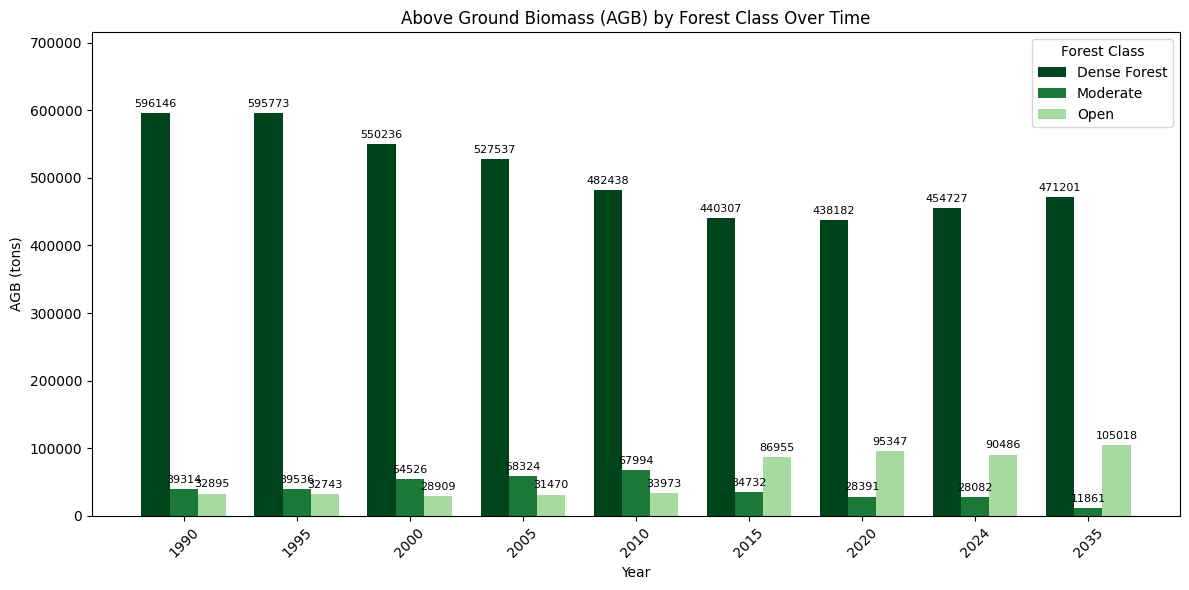

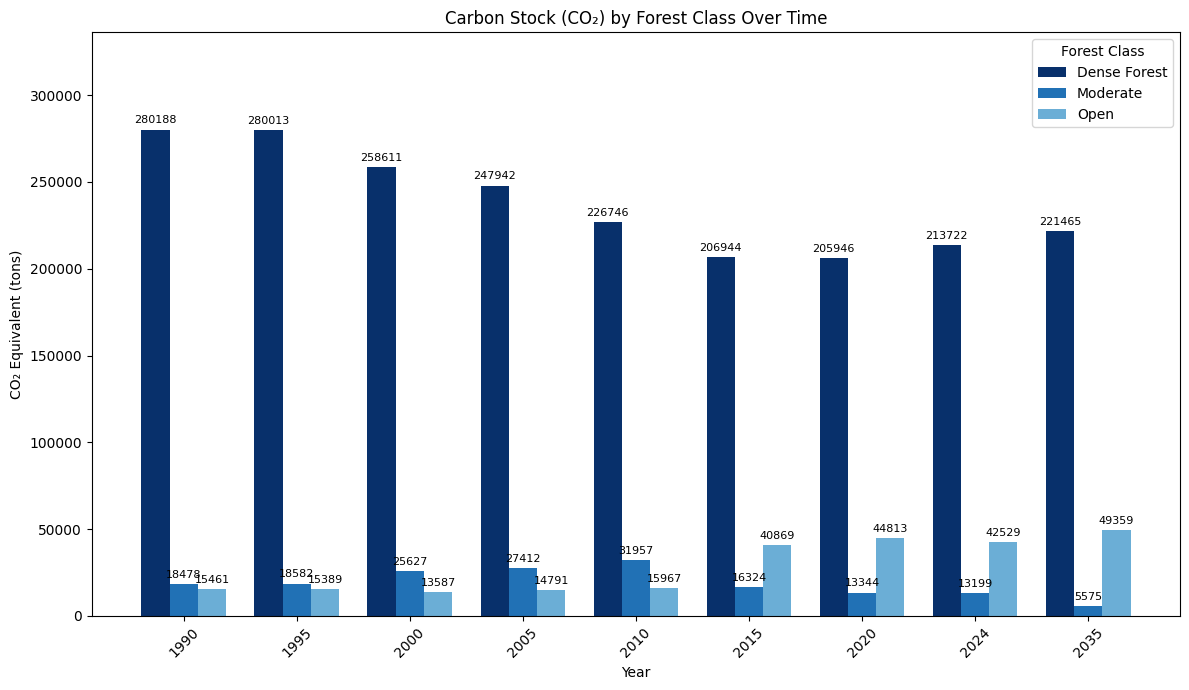

In [ ]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Define class labels and colors
class_labels = {0: "Dense Forest", 1: "Moderate", 2: "Open"}
colors = ['#00441b', '#1b7837', '#a6dba0']  # Dark to light greens

# Collect GeoJSON files
folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"
files = sorted([
    f for f in os.listdir(folder)
    if f.endswith(".geojson") and "Polygons" in f
], key=lambda x: int(''.join(filter(str.isdigit, x))))

# Aggregate AGB and CO2 per class over years
year_class_agb = {}
year_class_co2 = {}

for file in files:
    year = ''.join(filter(str.isdigit, file))
    path = os.path.join(folder, file)
    gdf = gpd.read_file(path)

    for cls in [0, 1, 2]:
        agb = gdf[gdf["class"] == cls]["AGB_tons"].sum()
        co2 = gdf[gdf["class"] == cls]["CO2_tons"].sum()
        year_class_agb.setdefault(year, []).append(agb)
        year_class_co2.setdefault(year, []).append(co2)

# Sort by year
years = list(year_class_agb.keys())
years.sort()

# Convert to arrays
agb_data = np.array([year_class_agb[yr] for yr in years])  # shape (n_years, 3)
co2_data = np.array([year_class_co2[yr] for yr in years])

x = np.arange(len(years))
width = 0.25

# --- Plot AGB ---
fig, ax = plt.subplots(figsize=(12, 6))

for i in range(3):
    bars = ax.bar(x + i * width, agb_data[:, i], width, label=class_labels[i], color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

ax.set_title("Above Ground Biomass (AGB) by Forest Class Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("AGB (tons)")
ax.set_xticks(x + width)
ax.set_xticklabels(years, rotation=45)
ax.legend(title="Forest Class")
ax.set_ylim(0, np.max(agb_data) * 1.2)  # add headroom

plt.tight_layout()
plt.show()

# --- Plot CO2 ---
fig, ax = plt.subplots(figsize=(12, 7))

co2_colors = ['#08306b', '#2171b5', '#6baed6']  # More pronounced blues

for i in range(3):
    bars = ax.bar(x + i * width, co2_data[:, i], width, label=class_labels[i], color=co2_colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

ax.set_title("Carbon Stock (CO₂) by Forest Class Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("CO₂ Equivalent (tons)")
ax.set_xticks(x + width)
ax.set_xticklabels(years, rotation=45)
ax.legend(title="Forest Class")
ax.set_ylim(0, np.max(co2_data) * 1.2)  # add headroom

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Build combined DataFrame
rows = []
for i, year in enumerate(years):
    for cls in range(3):
        rows.append({
            "Year": int(year),
            "Class": class_labels[cls],
            "AGB_tons": agb_data[i, cls],
            "CO2_tons": co2_data[i, cls]
        })

# Create DataFrame
df_forest_summary = pd.DataFrame(rows)

# Preview
print(df_forest_summary)

# Optionally save to CSV
df_forest_summary.to_csv("forest_class_agb_co2_summary.csv", index=False)


    Year         Class       AGB_tons       CO2_tons
0   1990  Dense Forest  596145.670407  280188.465091
1   1990      Moderate   39314.312661   18477.726951
2   1990          Open   32895.139197   15460.715423
3   1995  Dense Forest  595773.314654  280013.457887
4   1995      Moderate   39536.054925   18581.945815
5   1995          Open   32743.056976   15389.236779
6   2000  Dense Forest  550236.050216  258610.943602
7   2000      Moderate   54525.636218   25627.049022
8   2000          Open   28908.883795   13587.175383
9   2005  Dense Forest  527537.201783  247942.484838
10  2005      Moderate   58323.928105   27412.246209
11  2005          Open   31469.709428   14790.763431
12  2010  Dense Forest  482437.771982  226745.752832
13  2010      Moderate   67993.969335   31957.165587
14  2010          Open   33972.790370   15967.211474
15  2015  Dense Forest  440307.397523  206944.476836
16  2015      Moderate   34732.168796   16324.119334
17  2015          Open   86954.527230   40868.

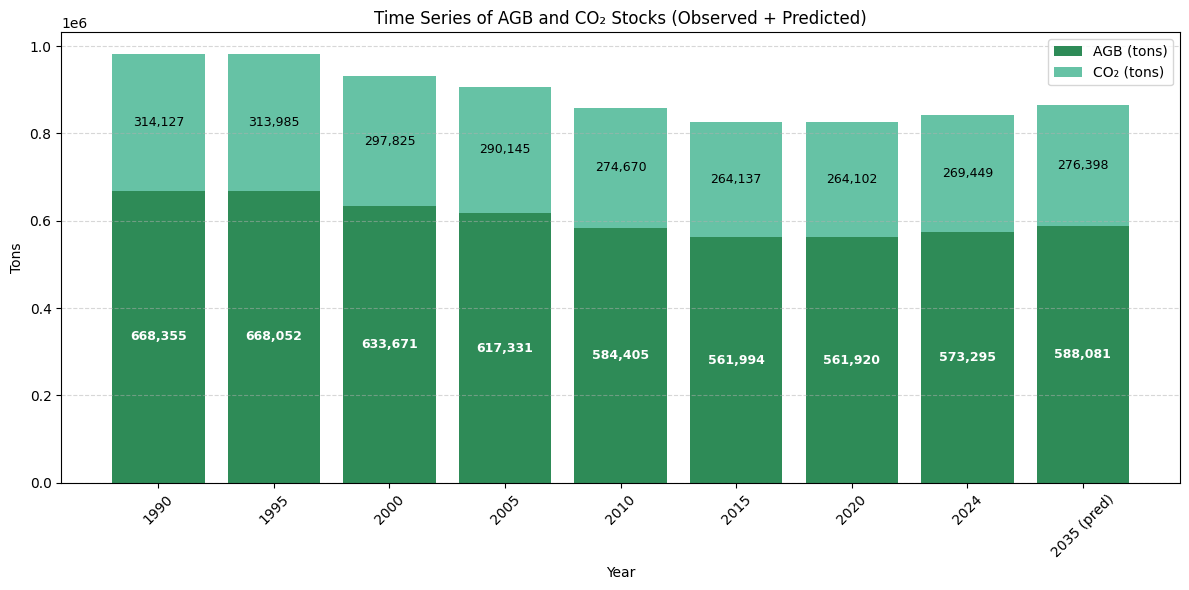

In [ ]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import re

# Directory containing GeoJSON files
geojson_dir = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"

# List all GeoJSON files
geojson_files = [f for f in os.listdir(geojson_dir) if f.endswith(".geojson")]

# Initialize time series data list
time_series_data = []

for file in geojson_files:
    try:
        # Extract year from filename using regex
        match = re.search(r"(19|20)\d{2}", file)
        if match:
            year = int(match.group())
        else:
            continue  # Skip if no year found

        is_predicted = "predicted" in file.lower()

        # Load GeoJSON
        gdf = gpd.read_file(os.path.join(geojson_dir, file))

        total_agb = gdf["AGB_tons"].sum()
        total_co2 = gdf["CO2_tons"].sum()

        time_series_data.append({
            "year": year,
            "AGB_tons": total_agb,
            "CO2_tons": total_co2,
            "predicted": is_predicted
        })

    except Exception as e:
        print(f" Failed to process {file}: {e}")

# Convert to DataFrame
df = pd.DataFrame(time_series_data).sort_values("year")
df["label"] = df["year"].astype(str)
df.loc[df["predicted"], "label"] += " (pred)"

# Plot
plt.figure(figsize=(12, 6))
bar1 = plt.bar(df["label"], df["AGB_tons"], label="AGB (tons)", color="#2e8b57")
bar2 = plt.bar(df["label"], df["CO2_tons"], bottom=df["AGB_tons"], label="CO₂ (tons)", color="#66c2a5")

# Add value labels
for i, (agb, co2) in enumerate(zip(df["AGB_tons"], df["CO2_tons"])):
    total = agb + co2
    plt.text(i, agb / 2, f"{agb:,.0f}", ha="center", va="center", fontsize=9, color="white", fontweight='bold')
    plt.text(i, agb + co2 / 2, f"{co2:,.0f}", ha="center", va="center", fontsize=9, color="black")

# Styling
plt.title("Time Series of AGB and CO₂ Stocks (Observed + Predicted)")
plt.xlabel("Year")
plt.ylabel("Tons")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df.head(10)

,year,AGB_tons,CO2_tons,predicted,label
2,1990,668355.122265,314126.907465,False,1990
7,1995,668052.426555,313984.640481,False,1995
1,2000,633670.570229,297825.168008,False,2000
3,2005,617330.839317,290145.494479,False,2005
4,2010,584404.531687,274670.129893,False,2010
0,2015,561994.093549,264137.223968,False,2015
6,2020,561920.093185,264102.443797,False,2020
5,2024,573294.942905,269448.623165,False,2024
8,2035,588080.796245,276397.974235,True,2035 (pred)


In [ ]:
import geopandas as gpd

# Paths
polygon_path = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_RF.geojson"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_path = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_RF_clipped.geojson"

# Load data
gdf = gpd.read_file(polygon_path)
mask = gpd.read_file(mask_path)

# Ensure both are in the same CRS
if gdf.crs != mask.crs:
    mask = mask.to_crs(gdf.crs)

# Clip
clipped = gpd.clip(gdf, mask)

# Save the result
clipped.to_file(output_path, driver="GeoJSON")
print(f"Clipped GeoJSON saved to: {output_path}")
print(f"Remaining features after clipping: {len(clipped)}")


Clipped GeoJSON saved to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_predicted_LULC_2035_RF_clipped.geojson
Remaining features after clipping: 1496


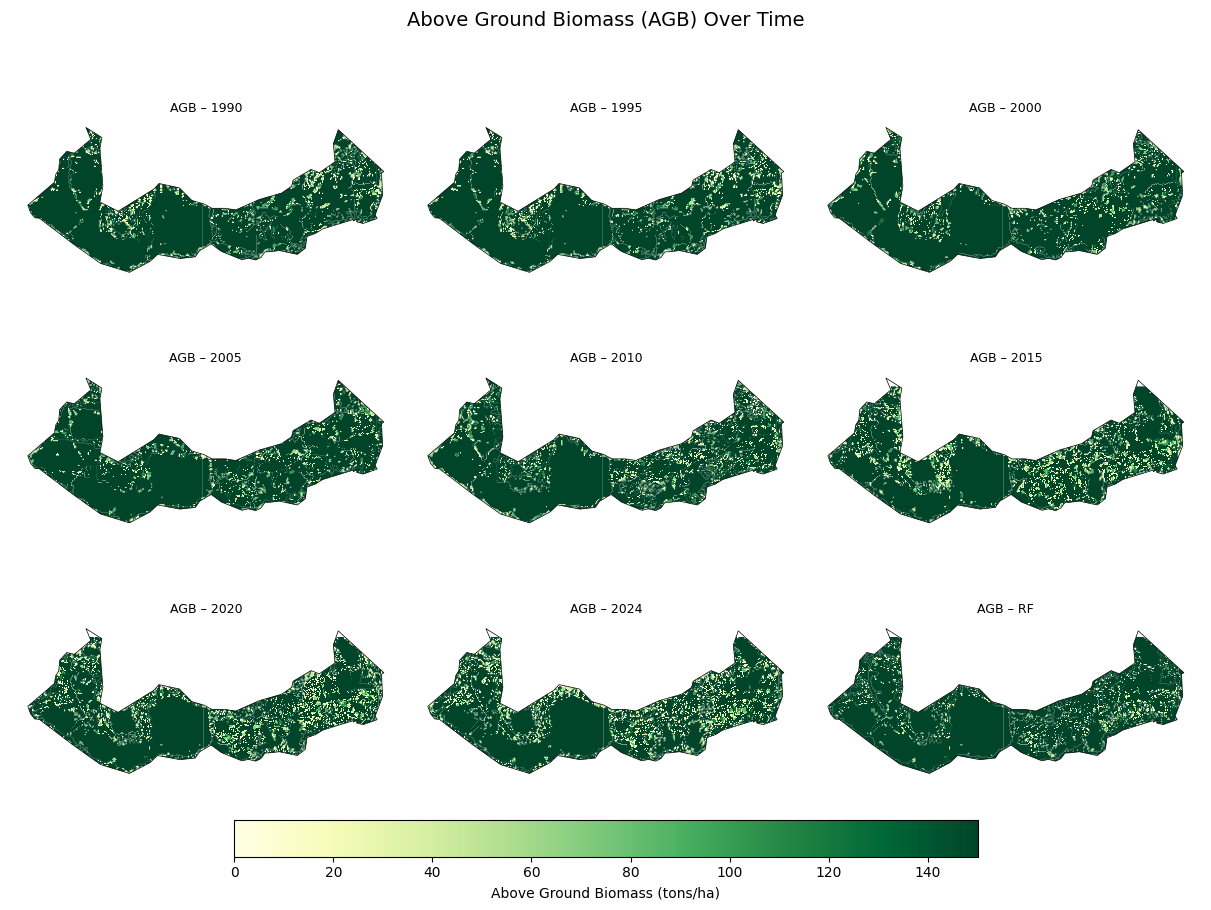

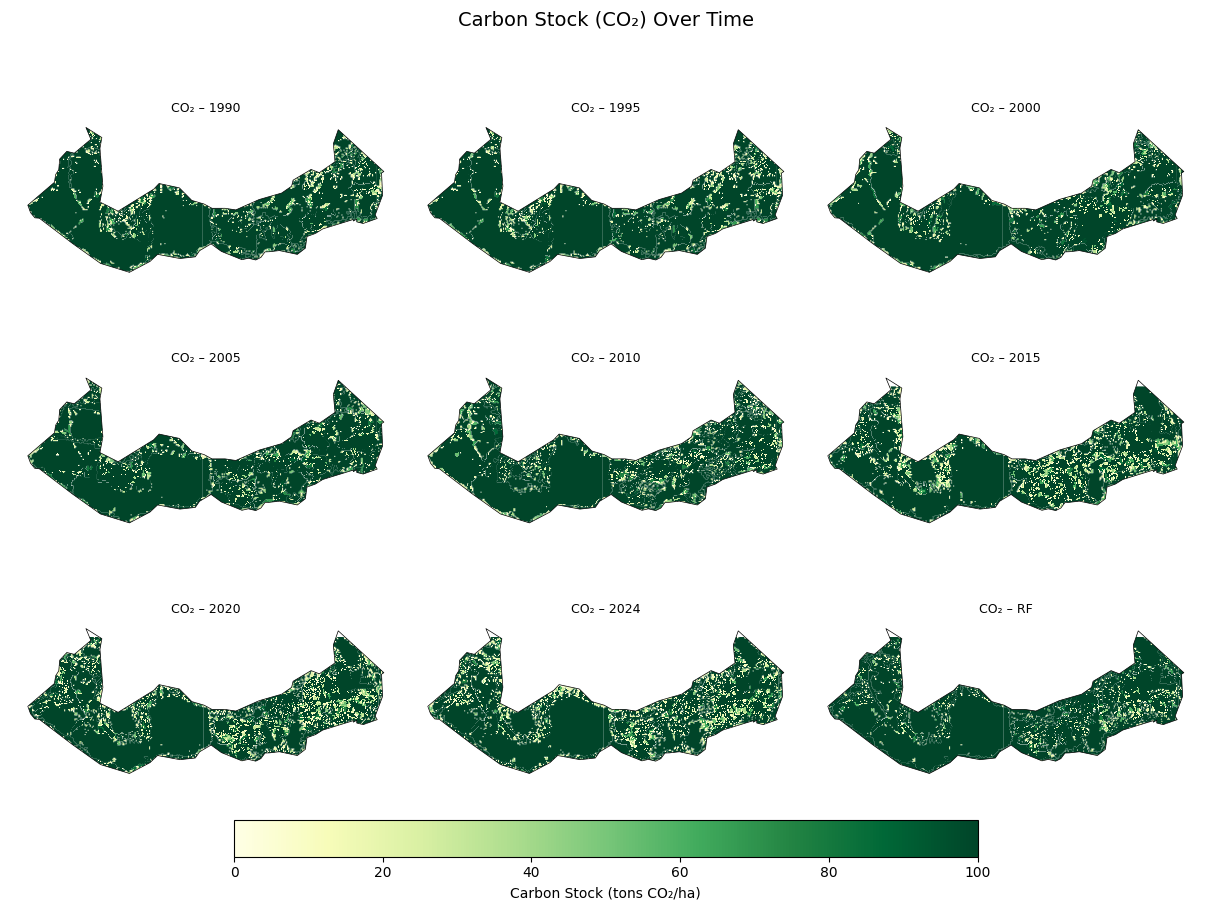

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# Paths
folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Load boundary
boundary = gpd.read_file(mask_path)

# Files and labels
files = [
    'Polygons_clipped_image_1990.geojson',
    'Polygons_clipped_image_1995.geojson',
    'Polygons_clipped_image_2000.geojson',
    'Polygons_clipped_image_2005.geojson',
    'Polygons_clipped_image_2010.geojson',
    'Polygons_clipped_image_2015.geojson',
    'Polygons_clipped_image_2020.geojson',
    'Polygons_clipped_image_2024.geojson',
    'Polygons_predicted_LULC_2035_RF.geojson',
]
titles = [f.split("_")[-1].replace(".geojson", "") for f in files]

# Color settings
cmap = 'YlGn'
vmin_agb, vmax_agb = 0, 150
vmin_co2, vmax_co2 = 0, 100

# Layout: 3 rows × 3 columns
ncols = 3
nrows = 3

# --- Plot AGB ---
fig_agb, axs_agb = plt.subplots(nrows, ncols, figsize=(12, 9), constrained_layout=True)
for i, file in enumerate(files):
    gdf = gpd.read_file(os.path.join(folder, file))
    gdf = gpd.clip(gdf, boundary)
    ax = axs_agb[i // ncols, i % ncols]
    gdf.plot(column='AGB_tons', ax=ax, cmap=cmap, legend=False, vmin=vmin_agb, vmax=vmax_agb)
    boundary.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title(f"AGB – {titles[i]}", fontsize=9)
    ax.axis('off')

# Add colorbar for AGB
norm_agb = mcolors.Normalize(vmin=vmin_agb, vmax=vmax_agb)
cbar_agb = fig_agb.colorbar(
    plt.cm.ScalarMappable(norm=norm_agb, cmap=cmap),
    ax=axs_agb,
    orientation='horizontal',
    fraction=0.05,
    pad=0.05
)
cbar_agb.set_label("Above Ground Biomass (tons/ha)", fontsize=10)
fig_agb.suptitle("Above Ground Biomass (AGB) Over Time", fontsize=14)
plt.show()

# --- Plot CO₂ ---
fig_co2, axs_co2 = plt.subplots(nrows, ncols, figsize=(12, 9), constrained_layout=True)
for i, file in enumerate(files):
    gdf = gpd.read_file(os.path.join(folder, file))
    gdf = gpd.clip(gdf, boundary)
    ax = axs_co2[i // ncols, i % ncols]
    gdf.plot(column='CO2_tons', ax=ax, cmap=cmap, legend=False, vmin=vmin_co2, vmax=vmax_co2)
    boundary.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title(f"CO₂ – {titles[i]}", fontsize=9)
    ax.axis('off')

# Add colorbar for CO₂
norm_co2 = mcolors.Normalize(vmin=vmin_co2, vmax=vmax_co2)
cbar_co2 = fig_co2.colorbar(
    plt.cm.ScalarMappable(norm=norm_co2, cmap=cmap),
    ax=axs_co2,
    orientation='horizontal',
    fraction=0.05,
    pad=0.05
)
cbar_co2.set_label("Carbon Stock (tons CO₂/ha)", fontsize=10)
fig_co2.suptitle("Carbon Stock (CO₂) Over Time", fontsize=14)
plt.show()


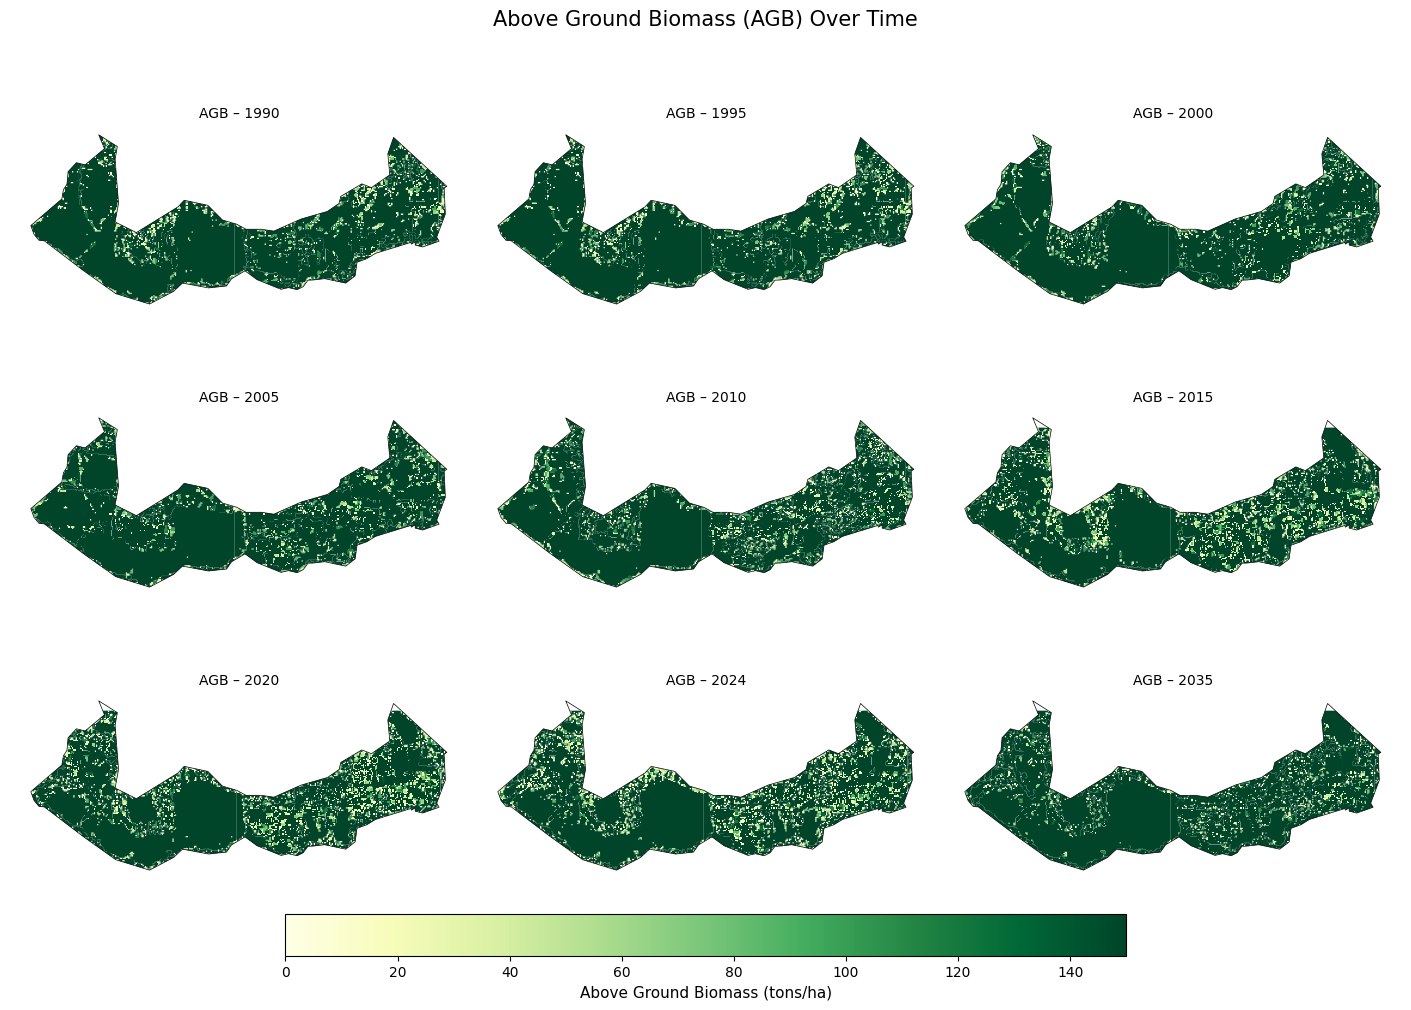

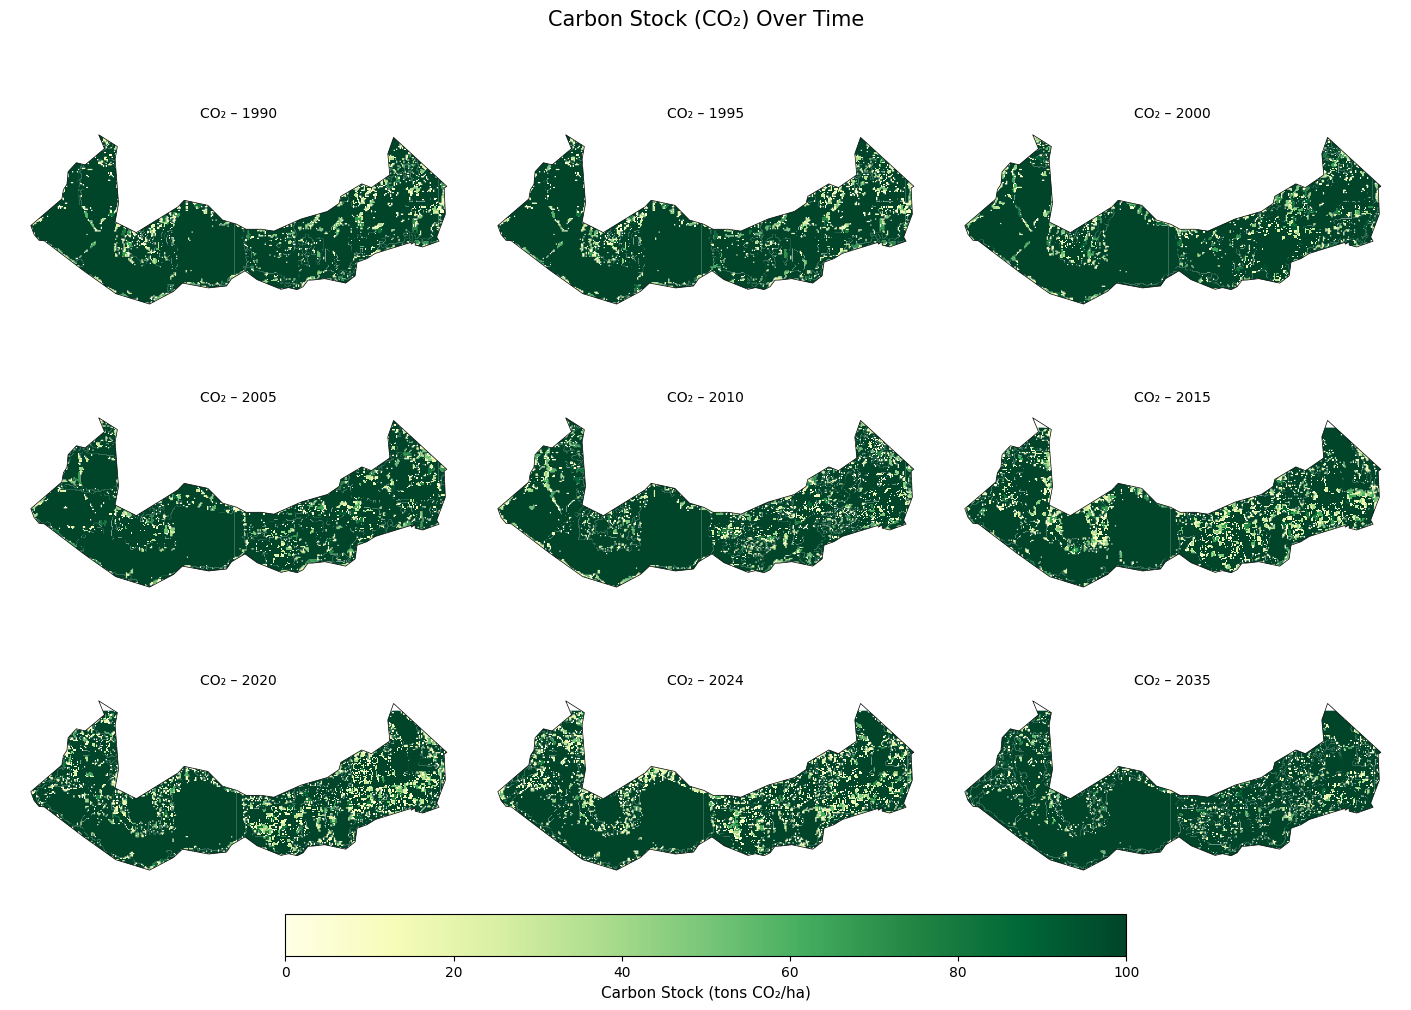

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# --- Paths ---
folder = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Load boundary
boundary = gpd.read_file(mask_path)

# GeoJSON files & titles
files = [
    'Polygons_clipped_image_1990.geojson',
    'Polygons_clipped_image_1995.geojson',
    'Polygons_clipped_image_2000.geojson',
    'Polygons_clipped_image_2005.geojson',
    'Polygons_clipped_image_2010.geojson',
    'Polygons_clipped_image_2015.geojson',
    'Polygons_clipped_image_2020.geojson',
    'Polygons_clipped_image_2024.geojson',
    'Polygons_predicted_LULC_2035_XGB_predicted.geojson',
]
titles = []
for f in files:
    if "2035" in f:
        titles.append("2035")
    else:
        titles.append(f.split("_")[-1].replace(".geojson", ""))


# --- Color settings ---
cmap = 'YlGn'
vmin_agb, vmax_agb = 0, 150
vmin_co2, vmax_co2 = 0, 100

# Layout: 3x3
ncols, nrows = 3, 3

# --- Plot AGB ---
fig_agb, axs_agb = plt.subplots(nrows, ncols, figsize=(14, 10), constrained_layout=True)
for i, file in enumerate(files):
    gdf = gpd.read_file(os.path.join(folder, file))
    gdf = gpd.clip(gdf, boundary)
    ax = axs_agb[i // ncols, i % ncols]
    gdf.plot(column='AGB_tons', ax=ax, cmap=cmap, legend=False, vmin=vmin_agb, vmax=vmax_agb)
    boundary.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title(f"AGB – {titles[i]}", fontsize=10)
    ax.axis('off')

# AGB Colorbar
norm_agb = mcolors.Normalize(vmin=vmin_agb, vmax=vmax_agb)
cbar_agb = fig_agb.colorbar(
    plt.cm.ScalarMappable(norm=norm_agb, cmap=cmap),
    ax=axs_agb,
    orientation='horizontal',
    fraction=0.05,
    pad=0.04
)
cbar_agb.set_label("Above Ground Biomass (tons/ha)", fontsize=11)
fig_agb.suptitle("Above Ground Biomass (AGB) Over Time", fontsize=15)
plt.show()

# --- Plot CO2 ---
fig_co2, axs_co2 = plt.subplots(nrows, ncols, figsize=(14, 10), constrained_layout=True)
for i, file in enumerate(files):
    gdf = gpd.read_file(os.path.join(folder, file))
    gdf = gpd.clip(gdf, boundary)
    ax = axs_co2[i // ncols, i % ncols]
    gdf.plot(column='CO2_tons', ax=ax, cmap=cmap, legend=False, vmin=vmin_co2, vmax=vmax_co2)
    boundary.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title(f"CO₂ – {titles[i]}", fontsize=10)
    ax.axis('off')

# CO2 Colorbar
norm_co2 = mcolors.Normalize(vmin=vmin_co2, vmax=vmax_co2)
cbar_co2 = fig_co2.colorbar(
    plt.cm.ScalarMappable(norm=norm_co2, cmap=cmap),
    ax=axs_co2,
    orientation='horizontal',
    fraction=0.05,
    pad=0.04
)
cbar_co2.set_label("Carbon Stock (tons CO₂/ha)", fontsize=11)
fig_co2.suptitle("Carbon Stock (CO₂) Over Time", fontsize=15)
plt.show()


In [ ]:
import geopandas as gpd
import os
import pandas as pd

# Path to directory containing GeoJSONs
geojson_dir = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"

# Collect all GeoJSON file paths
geojson_files = sorted([
    f for f in os.listdir(geojson_dir) if f.endswith(".geojson")
])

# Initialize summary list
summary_stats = []

for file in geojson_files:
    gdf = gpd.read_file(os.path.join(geojson_dir, file))

    # Try to extract year
    if "2035" in file:
        year = 2035
    else:
        try:
            year = int(file.split("_")[-1].replace(".geojson", ""))
        except ValueError:
            continue  # Skip if year not parsable

    # Sum AGB and CO2
    total_agb = gdf["AGB_tons"].sum()
    total_co2 = gdf["CO2_tons"].sum()

    summary_stats.append({
        "Year": year,
        "Total_AGB_tons": round(total_agb, 2),
        "Total_CO2_tons": round(total_co2, 2)
    })

# Create summary DataFrame
summary_df = pd.DataFrame(summary_stats).sort_values("Year").reset_index(drop=True)

# Display summary
print(summary_df)


   Year  Total_AGB_tons  Total_CO2_tons
0  1990       668355.12       314126.91
1  1995       668052.43       313984.64
2  2000       633670.57       297825.17
3  2005       617330.84       290145.49
4  2010       584404.53       274670.13
5  2015       561994.09       264137.22
6  2020       561920.09       264102.44
7  2024       573294.94       269448.62
8  2035       588080.80       276397.97


In [ ]:
summary_df.head(20)

,Year,Total_AGB_tons,Total_CO2_tons
0,1990,668355.12,314126.91
1,1995,668052.43,313984.64
2,2000,633670.57,297825.17
3,2005,617330.84,290145.49
4,2010,584404.53,274670.13
5,2015,561994.09,264137.22
6,2020,561920.09,264102.44
7,2024,573294.94,269448.62
8,2035,588080.80,276397.97


In [ ]:
import geopandas as gpd
import os
import pandas as pd

# Define your data folder
geojson_dir = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"

# List all GeoJSON files
geojson_files = sorted([
    f for f in os.listdir(geojson_dir) if f.endswith(".geojson")
])

# Initialize list to hold per-class summaries
summary_by_class = []

for file in geojson_files:
    gdf = gpd.read_file(os.path.join(geojson_dir, file))

    # Determine year
    if "2035" in file:
        year = 2035
    else:
        try:
            year = int(file.split("_")[-1].replace(".geojson", ""))
        except ValueError:
            continue  # Skip file if year is not found

    # Group by class and sum AGB and CO2
    grouped = gdf.groupby("class")[["AGB_tons", "CO2_tons"]].sum().reset_index()
    grouped["Year"] = year

    # Append to master list
    summary_by_class.append(grouped)

# Combine all into a single DataFrame
summary_df = pd.concat(summary_by_class, ignore_index=True)

# Sort by year and class
summary_df = summary_df.sort_values(by=["Year", "class"]).reset_index(drop=True)

# Round values for neatness
summary_df["AGB_tons"] = summary_df["AGB_tons"].round(2)
summary_df["CO2_tons"] = summary_df["CO2_tons"].round(2)

# Display sample
print(summary_df.head())


   class   AGB_tons   CO2_tons  Year
0      0  596145.67  280188.47  1990
1      1   39314.31   18477.73  1990
2      2   32895.14   15460.72  1990
3      0  595773.31  280013.46  1995
4      1   39536.05   18581.95  1995


In [ ]:
# Map class codes to descriptive names
class_labels = {
    0: "Dense Forest Class",
    1: "Moderate Forest Class",
    2: "Open Forest Class"
}

# Apply mapping to the 'class' column
summary_df["Forest_Class"] = summary_df["class"].map(class_labels)

# Reorder columns for clarity
summary_df = summary_df[["Year", "Forest_Class", "AGB_tons", "CO2_tons"]]

# Display updated summary


summary_df.head(10)

,Year,Forest_Class,AGB_tons,CO2_tons
0,1990,Dense Forest Class,596145.67,280188.47
1,1990,Moderate Forest Class,39314.31,18477.73
2,1990,Open Forest Class,32895.14,15460.72
3,1995,Dense Forest Class,595773.31,280013.46
4,1995,Moderate Forest Class,39536.05,18581.95
5,1995,Open Forest Class,32743.06,15389.24
6,2000,Dense Forest Class,550236.05,258610.94
7,2000,Moderate Forest Class,54525.64,25627.05
8,2000,Open Forest Class,28908.88,13587.18
9,2005,Dense Forest Class,527537.20,247942.48


In [ ]:
import geopandas as gpd
import pandas as pd
import os
from glob import glob

# Folder containing the GeoJSONs
geojson_dir = "/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles"

# Get all relevant GeoJSON files
geojson_files = sorted(glob(os.path.join(geojson_dir, "*.geojson")))

# Extract year from filenames
def extract_year_from_filename(path):
    name = os.path.basename(path)
    if "2035" in name:
        return 2035
    digits = ''.join(filter(str.isdigit, name))
    return int(digits) if digits else None

# Store stats here
summary_stats = []

for file in geojson_files:
    gdf = gpd.read_file(file)
    year = extract_year_from_filename(file)
    if year is None or 'class' not in gdf.columns:
        continue

    # For each class (0,1,2), compute stats
    for cls in gdf['class'].unique():
        subset = gdf[gdf['class'] == cls]
        stats = {
            'Year': year,
            'Class': cls,
            'Mean_AGB': subset['AGB_tons'].mean(),
            'Median_AGB': subset['AGB_tons'].median(),
            'Max_AGB': subset['AGB_tons'].max(),
            'Min_AGB': subset['AGB_tons'].min(),
            'Std_AGB': subset['AGB_tons'].std(),
            'Sum_AGB': subset['AGB_tons'].sum(),
            'Mean_CO2': subset['CO2_tons'].mean(),
            'Median_CO2': subset['CO2_tons'].median(),
            'Max_CO2': subset['CO2_tons'].max(),
            'Min_CO2': subset['CO2_tons'].min(),
            'Std_CO2': subset['CO2_tons'].std(),
            'Sum_CO2': subset['CO2_tons'].sum(),
            'Count': len(subset)
        }
        summary_stats.append(stats)

# Convert to DataFrame
summary_df_full = pd.DataFrame(summary_stats)

# Optional: rename class numbers
class_map = {0: "Dense Forest Class", 1: "Moderate Forest Class", 2: "Open Forest Class"}
summary_df_full['Class'] = summary_df_full['Class'].map(class_map)

# Sort for easy reading
summary_df_full = summary_df_full.sort_values(by=['Year', 'Class']).reset_index(drop=True)

# Preview
print(summary_df_full.head())


   Year                  Class     Mean_AGB  Median_AGB        Max_AGB  \
0  1990     Dense Forest Class  2356.306998   39.310928  364435.381552   
1  1990  Moderate Forest Class    64.029825   10.221135   17726.209355   
2  1990      Open Forest Class    73.100309   12.442916    5183.863332   
3  1995     Dense Forest Class  2336.365940   39.310928  361966.440868   
4  1995  Moderate Forest Class    64.813205   10.221139   17088.243051   

    Min_AGB       Std_AGB        Sum_AGB     Mean_CO2  Median_CO2  \
0  1.091968  25633.015962  596145.670407  1107.464289   18.476136   
1  0.283919    733.748843   39314.312661    30.094018    4.803933   
2  0.345633    325.217369   32895.139197    34.357145    5.848170   
3  1.091968  25392.572562  595773.314654  1098.091992   18.476136   
4  0.283919    709.606843   39536.054925    30.462206    4.803935   

         Max_CO2   Min_CO2       Std_CO2        Sum_CO2  Count  
0  171284.629330  0.513225  12047.517502  280188.465091    253  
1    8331.

In [ ]:
summary_df_full.tail(10)

,Year,Class,Mean_AGB,Median_AGB,Max_AGB,Min_AGB,Std_AGB,Sum_AGB,Mean_CO2,Median_CO2,Max_CO2,Min_CO2,Std_CO2,Sum_CO2,Count
23,2024,Open Forest Class,134.053658,12.442904,12620.222965,0.345633,711.583459,90486.219353,63.005219,5.848165,5931.504793,0.162447,334.444226,42528.523096,675
24,2035,Dense Forest Class,901.098978,39.310846,299961.089666,1.091965,13433.003037,470373.666730,423.516520,18.476098,140981.712143,0.513224,6313.511428,221075.623363,522
25,2035,Dense Forest Class,900.808968,39.310842,299922.198989,0.676449,13431.282554,470222.281427,423.380215,18.476096,140963.433525,0.317931,6312.702800,221004.472271,522
26,2035,Dense Forest Class,979.628544,39.310891,287605.453736,1.091963,13485.138720,471201.329865,460.425416,18.476119,135174.563256,0.513223,6338.015199,221464.625036,481
27,2035,Moderate Forest Class,23.188839,10.221098,1086.275188,0.283919,91.850294,12661.106061,10.898754,4.803916,510.549338,0.133442,43.169638,5950.719849,546
28,2035,Moderate Forest Class,23.172912,10.221098,1086.275188,0.154552,91.852523,12652.410001,10.891269,4.803916,510.549338,0.072639,43.170686,5946.632700,546
29,2035,Moderate Forest Class,24.206171,10.221108,1134.541473,0.283918,96.068725,11861.023607,11.376900,4.803921,533.234493,0.133442,45.152301,5574.681095,490
30,2035,Open Forest Class,958.868853,12.442872,208373.416144,0.345634,13045.497089,410395.869084,450.668361,5.848150,97935.505588,0.162448,6131.383632,192886.058469,428
31,2035,Open Forest Class,243.852938,12.442872,51420.838601,0.345634,2888.129109,104369.057478,114.610881,5.848150,24167.794143,0.162448,1357.420681,49053.457015,428
32,2035,Open Forest Class,206.729218,12.442868,25325.408230,0.345635,1460.921346,105018.442773,97.162732,5.848148,11902.941868,0.162448,686.633032,49358.668103,508


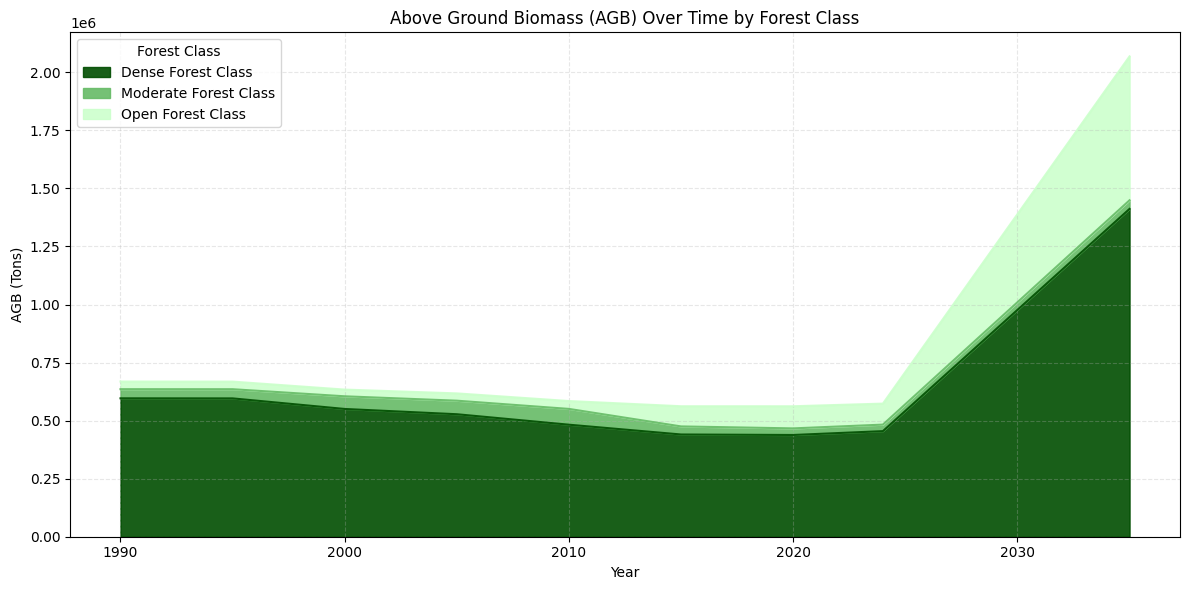

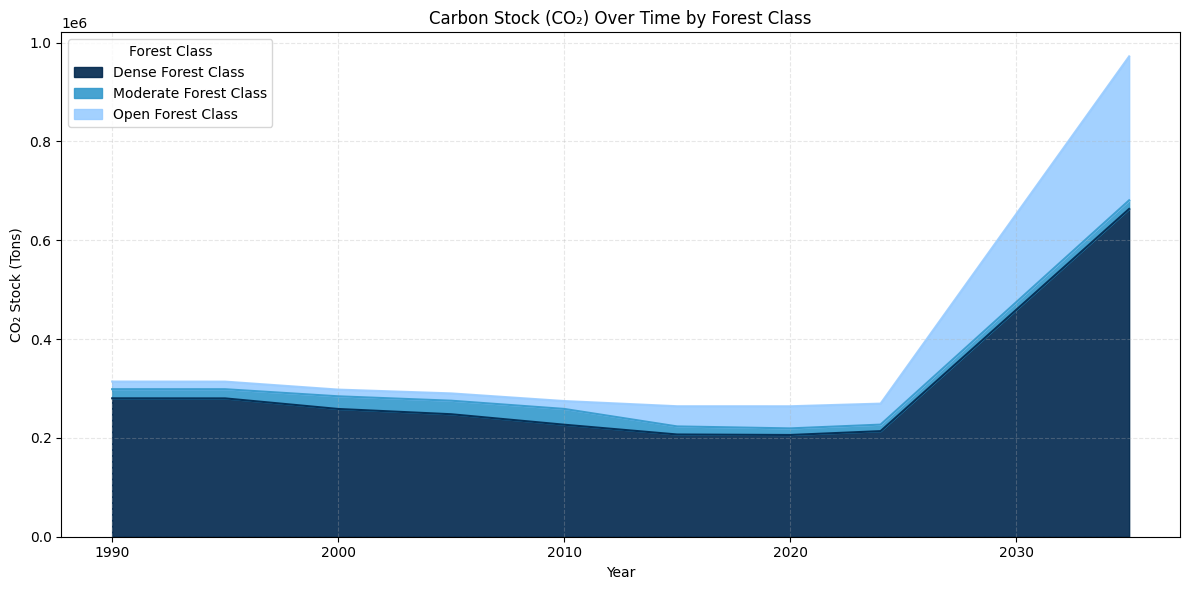

In [ ]:
# Group to handle duplicate year/class combinations
grouped_df = summary_df_full.groupby(['Year', 'Class'], as_index=False).sum()

# Pivot after grouping
agb_pivot = grouped_df.pivot(index='Year', columns='Class', values='Sum_AGB').fillna(0)
co2_pivot = grouped_df.pivot(index='Year', columns='Class', values='Sum_CO2').fillna(0)

# Sort index just in case
agb_pivot = agb_pivot.sort_index()
co2_pivot = co2_pivot.sort_index()

# Define colors
agb_colors = ['#004d00', '#66bb66', '#ccffcc']  # Dense, Moderate, Open
co2_colors = ['#00274d', '#3399cc', '#99ccff']  # Dense, Moderate, Open

# Plot AGB Stacked Area
plt.figure(figsize=(12, 6))
agb_pivot.plot.area(ax=plt.gca(), color=agb_colors, alpha=0.9)
plt.title("Above Ground Biomass (AGB) Over Time by Forest Class")
plt.ylabel("AGB (Tons)")
plt.xlabel("Year")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Forest Class', loc='upper left')
plt.tight_layout()
plt.show()

# Plot CO₂ Stacked Area
plt.figure(figsize=(12, 6))
co2_pivot.plot.area(ax=plt.gca(), color=co2_colors, alpha=0.9)
plt.title("Carbon Stock (CO₂) Over Time by Forest Class")
plt.ylabel("CO₂ Stock (Tons)")
plt.xlabel("Year")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Forest Class', loc='upper left')
plt.tight_layout()
plt.show()


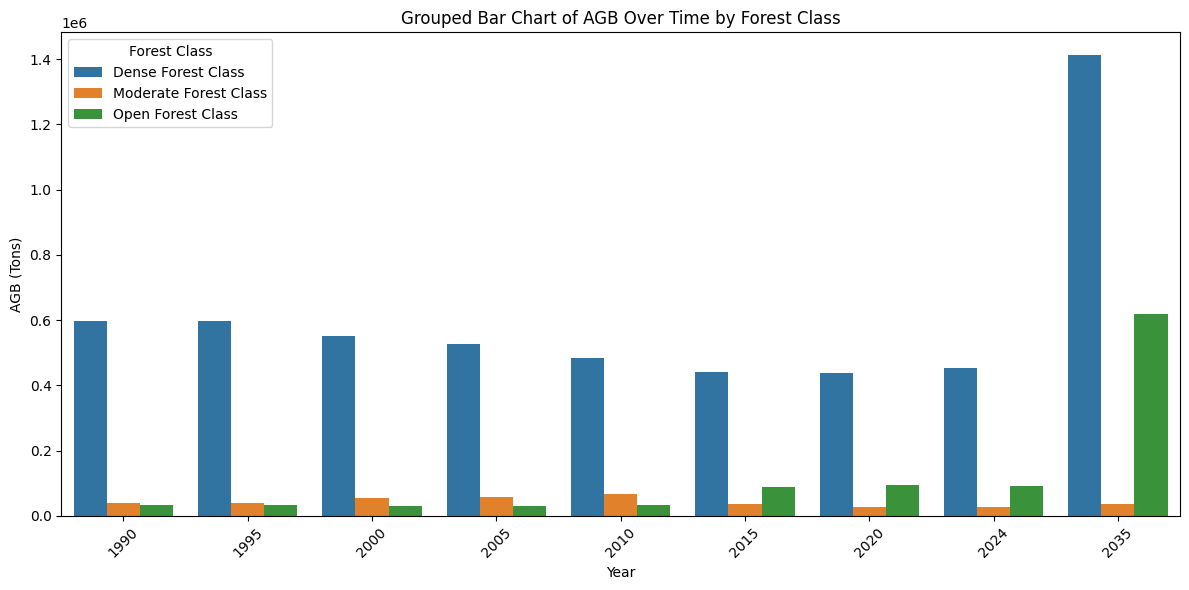

In [ ]:
# Same `grouped_df` from earlier
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_df, x='Year', y='Sum_AGB', hue='Class')
plt.title("Grouped Bar Chart of AGB Over Time by Forest Class")
plt.ylabel("AGB (Tons)")
plt.xlabel("Year")
plt.legend(title="Forest Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
